In [1]:
!pip install seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 5.4 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.0.1 -> 23.3.1
[notice] To update, run: pip install --upgrade pip


In [2]:
#Dependencies
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

D1026 07:25:27.205922401      14 config.cc:119]                        gRPC EXPERIMENT tcp_frame_size_tuning               OFF (default:OFF)
D1026 07:25:27.205946417      14 config.cc:119]                        gRPC EXPERIMENT tcp_rcv_lowat                       OFF (default:OFF)
D1026 07:25:27.205949944      14 config.cc:119]                        gRPC EXPERIMENT peer_state_based_framing            OFF (default:OFF)
D1026 07:25:27.205952674      14 config.cc:119]                        gRPC EXPERIMENT flow_control_fixes                  ON  (default:ON)
D1026 07:25:27.205955255      14 config.cc:119]                        gRPC EXPERIMENT memory_pressure_controller          OFF (default:OFF)
D1026 07:25:27.205957821      14 config.cc:119]                        gRPC EXPERIMENT unconstrained_max_quota_buffer_size OFF (default:OFF)
D1026 07:25:27.205960051      14 config.cc:119]                        gRPC EXPERIMENT new_hpack_huffman_decoder           ON  (default:ON)
D1026 07:25:27.

In [3]:
#CONSTs
IMG_WIDTH, IMG_HEIGHT = 150, 150
BATCH_SIZE = 32

In [4]:
# Importing datas
train_dir = "/kaggle/input/chest-xray-pneumonia/chest_xray/train"
train_normal = len(os.listdir(os.path.join(train_dir, "NORMAL")))
train_pneumonia = len(os.listdir(os.path.join(train_dir, "PNEUMONIA")))

test_dir = "/kaggle/input/chest-xray-pneumonia/chest_xray/test/"
test_normal = len(os.listdir(os.path.join(test_dir, "NORMAL")))
test_pneumonia = len(os.listdir(os.path.join(test_dir, "PNEUMONIA")))

val_dir = "/kaggle/input/chest-xray-pneumonia/chest_xray/val"
val_normal = len(os.listdir(os.path.join(val_dir, "NORMAL")))
val_pneumonia = len(os.listdir(os.path.join(val_dir, "PNEUMONIA")))

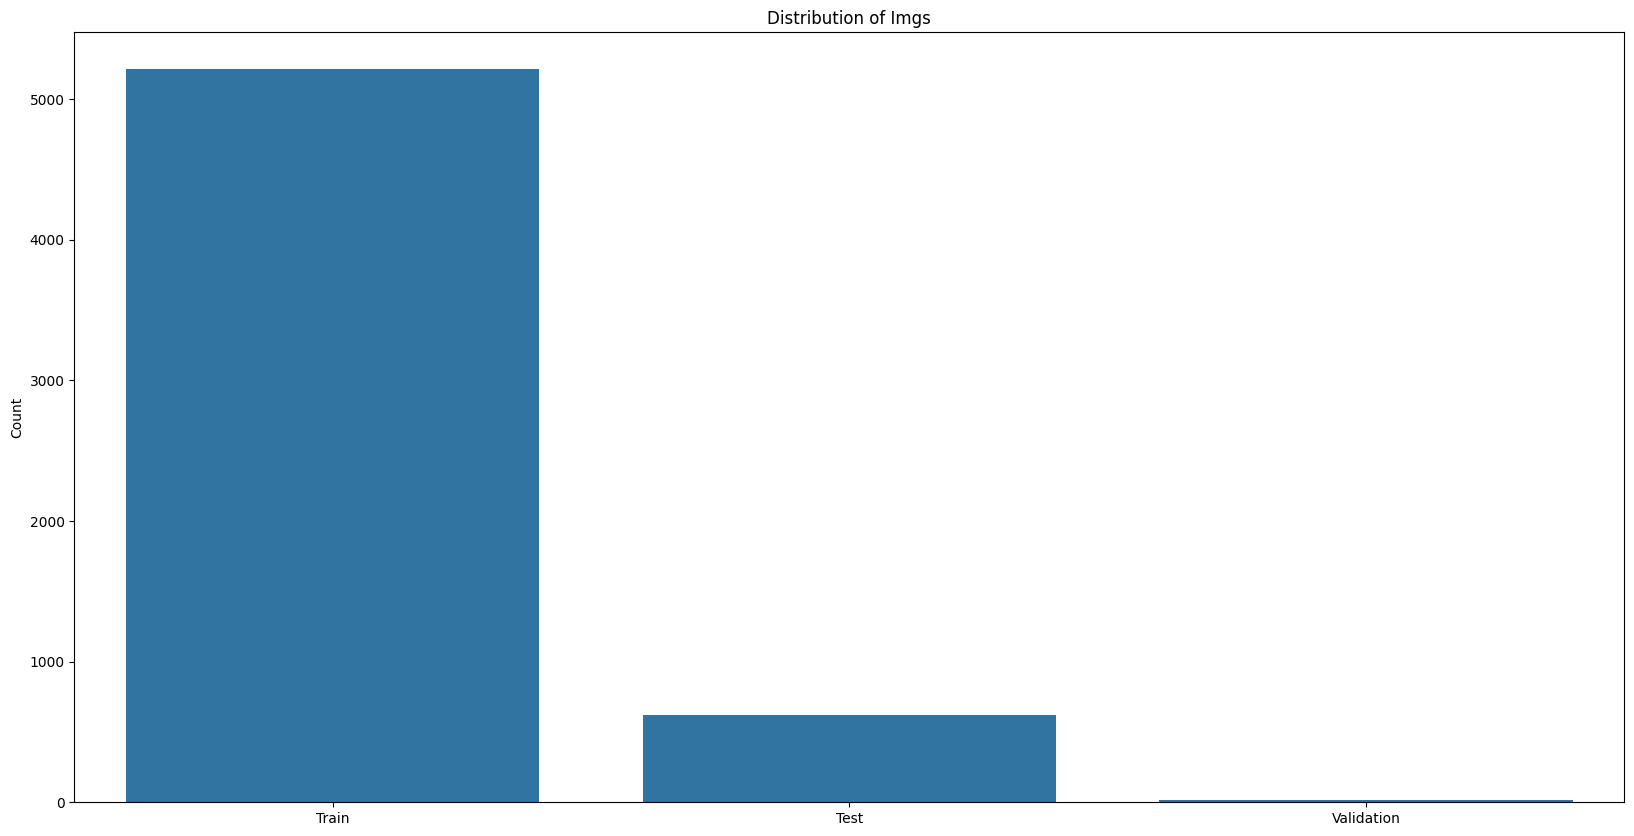

In [5]:
# Simple EDA
plt.figure(figsize=(20, 10))
sns.barplot(x=["Train", "Test", "Validation"], y=[train_normal + train_pneumonia, test_normal + test_pneumonia, val_normal + val_pneumonia])
plt.title("Distribution of Imgs")
plt.ylabel("Count")
plt.show()

In [6]:
# Data Augmentation

train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1.0/255.0)

In [7]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

validation_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [8]:
# Model
model = Sequential()

model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_WIDTH, IMG_HEIGHT, 3)))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.0001), metrics=['accuracy'])

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=30,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE
)

Epoch 1/30
163/163 [==============================] - 104s 627ms/step - loss: 0.5375 - accuracy: 0.7487
Epoch 2/30
163/163 [==============================] - 75s 456ms/step - loss: 0.3767 - accuracy: 0.8148
Epoch 3/30
163/163 [==============================] - 75s 457ms/step - loss: 0.3202 - accuracy: 0.8533
Epoch 4/30
163/163 [==============================] - 74s 455ms/step - loss: 0.2926 - accuracy: 0.8679
Epoch 5/30
163/163 [==============================] - 75s 456ms/step - loss: 0.2726 - accuracy: 0.8752
Epoch 6/30
163/163 [==============================] - 74s 454ms/step - loss: 0.2704 - accuracy: 0.8846
Epoch 7/30
163/163 [==============================] - 74s 455ms/step - loss: 0.2587 - accuracy: 0.8880
Epoch 8/30
163/163 [==============================] - 75s 456ms/step - loss: 0.2512 - accuracy: 0.8919
Epoch 9/30
163/163 [==============================] - 75s 458ms/step - loss: 0.2529 - accuracy: 0.8878
Epoch 10/30
163/163 [==============================] - 74s 456ms/step - 

19/19 [==============================] - 8s 429ms/step - loss: 0.2759 - accuracy: 0.8997
Test Loss: 0.27594703435897827
Test Accuracy: 0.8996710777282715
20/20 [==============================] - 5s 237ms/step
              precision    recall  f1-score   support

      Normal       0.37      0.31      0.34       234
   Pneumonia       0.62      0.68      0.65       390

    accuracy                           0.54       624
   macro avg       0.50      0.50      0.49       624
weighted avg       0.53      0.54      0.53       624



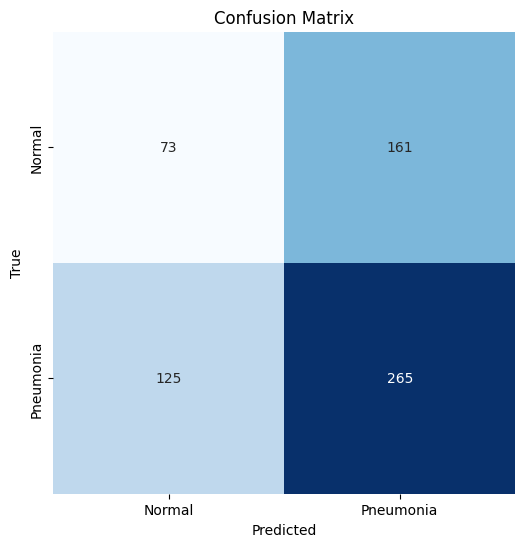

In [9]:
# Results
test_results = model.evaluate(test_generator, steps=test_generator.samples // BATCH_SIZE)
print("Test Loss:", test_results[0])
print("Test Accuracy:", test_results[1])

predictions = model.predict(test_generator)
y_pred = (predictions > 0.5).astype(int)

print(classification_report(test_generator.classes, y_pred, target_names=["Normal", "Pneumonia"]))
confusion_mtx = confusion_matrix(test_generator.classes, y_pred)

plt.figure(figsize=(6, 6))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Blues', cbar=False, square=True, xticklabels=["Normal", "Pneumonia"], yticklabels=["Normal", "Pneumonia"])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()